# Assignment 1
**Credits**: Federico Ruggeri, Eleonora Mancini, Paolo Torroni

**Keywords**: Sexism Detection, Multi-class Classification, RNNs, Transformers, Huggingface



# Contact
For any doubt, question, issue or help, you can always contact us at the following email addresses:

Teaching Assistants:

- Federico Ruggeri -> federico.ruggeri6@unibo.it
- Eleonora Mancini -> e.mancini@unibo.it

Professor:
- Paolo Torroni -> p.torroni@unibo.it

# Introduction
You are asked to address the [EXIST 2023 Task 2](https://clef2023.clef-initiative.eu/index.php?page=Pages/labs.html#EXIST) on sexism detection.

## Problem Definition

This task aims to categorize the sexist messages according to the intention of the author in one of the following categories: (i) direct sexist message, (ii) reported sexist message and (iii) judgemental message.

### Examples:

#### DIRECT 
The intention was to write a message that is sexist by itself or incites to be sexist, as in:

''*A woman needs love, to fill the fridge, if a man can give this to her in return for her services (housework, cooking, etc), I don’t see what else she needs.*''

#### REPORTED
The intention is to report and share a sexist situation suffered by a woman or women in first or third person, as in:

''*Today, one of my year 1 class pupils could not believe he’d lost a race against a girl.*''

#### JUDGEMENTAL
The intention was to judge, since the tweet describes sexist situations or behaviours with the aim of condemning them.

''*As usual, the woman was the one quitting her job for the family’s welfare…*''

# [Task 1 - 1.0 points] Corpus

We have preparared a small version of EXIST dataset in our dedicated [Github repository](https://github.com/lt-nlp-lab-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data).

Check the `A1/data` folder. It contains 3 `.json` files representing `training`, `validation` and `test` sets.


### Dataset Description
- The dataset contains tweets in both English and Spanish.
- There are labels for multiple tasks, but we are focusing on **Task 2**.
- For Task 2, labels are assigned by six annotators.
- The labels for Task 2 represent whether the tweet is non-sexist ('-') or its sexist intention ('DIRECT', 'REPORTED', 'JUDGEMENTAL').







### Example

```
    "203260": {
        "id_EXIST": "203260",
        "lang": "en",
        "tweet": "ik when mandy says “you look like a whore” i look cute as FUCK",
        "number_annotators": 6,
        "annotators": ["Annotator_473", "Annotator_474", "Annotator_475", "Annotator_476", "Annotator_477", "Annotator_27"],
        "gender_annotators": ["F", "F", "M", "M", "M", "F"],
        "age_annotators": ["18-22", "23-45", "18-22", "23-45", "46+", "46+"],
        "labels_task1": ["YES", "YES", "YES", "NO", "YES", "YES"],
        "labels_task2": ["DIRECT", "DIRECT", "REPORTED", "-", "JUDGEMENTAL", "REPORTED"],
        "labels_task3": [
          ["STEREOTYPING-DOMINANCE"],
          ["OBJECTIFICATION"],
          ["SEXUAL-VIOLENCE"],
          ["-"],
          ["STEREOTYPING-DOMINANCE", "OBJECTIFICATION"],
          ["OBJECTIFICATION"]
        ],
        "split": "TRAIN_EN"
      }
    }
```

### Instructions
1. **Download** the `A1/data` folder.
2. **Load** the three JSON files and encode them as ``pandas.DataFrame``.
3. **Aggregate labels** for Task 2 using majority voting and store them in a new dataframe column called `label`. Items without a clear majority will be removed from the dataset.
4. **Filter the DataFrame** to keep only rows where the `lang` column is `'en'`.
5. **Remove unwanted columns**: Keep only `id_EXIST`, `lang`, `tweet`, and `label`.
6. **Encode the `label` column**: Use the following mapping

```
{
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}
```

In [165]:
# system packages
from pathlib import Path
import shutil
import urllib
import tarfile
import sys

# data and numerical management packages
import pandas as pd
import numpy as np
import simplejson as sj

# useful during debugging (progress bars)
from tqdm import tqdm

# typing
from typing import List, Callable, Dict
from collections import OrderedDict

# pre-processing
import re
import nltk
from nltk.corpus import stopwords

# utility
from functools import reduce
from itertools import product
import zipfile
import gc
import requests
import time
import tensorflow as tf
from keras import Sequential
from keras.layers import Dense, Embedding, Bidirectional, LSTM, Dropout
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding,TrainingArguments, Trainer, set_seed
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report, confusion_matrix 

In [166]:
import os
print("Sei in:", os.getcwd())

Sei in: /Users/giorgioscavello/Documents/GitHub/NLP_project/GIO


In [167]:
import json
import pandas as pd
from collections import Counter

# Load and encode the jsons
train_df = pd.DataFrame(json.load(open('../A1/data/training.json'))).transpose()
test_df = pd.DataFrame(json.load(open('../A1/data/test.json'))).transpose()
val_df = pd.DataFrame(json.load(open('../A1/data/validation.json'))).transpose()
dfs = [train_df, val_df, test_df]

print("Before:", train_df.shape, val_df.shape, test_df.shape)

for i, df in enumerate(dfs):
    # Aggregate labels by majority vote, only keep rows with unique majority
    majority_labels = []
    for labels in df["labels_task2"]:
        c = Counter(labels).most_common(2)
        if len(c)==1:
            majority_labels.append(c[0][0])
        elif c[1][1] < c[0][1]:
            majority_labels.append(c[0][0])
        else:
            majority_labels.append(None)
    df["label"] = majority_labels
    df = df.dropna(subset=["label"]).reset_index(drop=True)

    # Filter rows with language "en"
    df = df[df["lang"]=="en"].reset_index(drop=True)
    df = df[["id_EXIST", "lang", "tweet", "label"]]

    # Encode labels as integers
    label_mapping = {"-":0, "DIRECT":1, "JUDGEMENTAL":2, "REPORTED":3}
    reverse_mapping = {v: k for k, v in label_mapping.items()}  # TODO: utile per debug ma togliere dopo
    df["label"] = df["label"].map(label_mapping)

    dfs[i] = df # NOTE: we have to do this otherwise the changes won't persist


train_df, val_df, test_df = dfs
print("After: ", train_df.shape, val_df.shape, test_df.shape)

Before: (6920, 11) (726, 11) (312, 11)
After:  (2873, 4) (150, 4) (280, 4)


# [Task2 - 0.5 points] Data Cleaning
In the context of tweets, we have noisy and informal data that often includes unnecessary elements like emojis, hashtags, mentions, and URLs. These elements may interfere with the text analysis.



### Instructions
- **Remove emojis** from the tweets.
- **Remove hashtags** (e.g., `#example`).
- **Remove mentions** such as `@user`.
- **Remove URLs** from the tweets.
- **Remove special characters and symbols**.
- **Remove specific quote characters** (e.g., curly quotes).
- **Perform lemmatization** to reduce words to their base form.

In [168]:
# ! pip install --upgrade pip
# ! pip install emoji

In [169]:
import re
import os
import nltk
from nltk import pos_tag, word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import emoji
import gensim
import gensim.downloader as gloader
import numpy as np

In [170]:
# Download required NLTK data
# NOTE: this is mostly from the lab, mayeb it's not the most efficient way
# Download required NLTK data
os.makedirs("nltk_data", exist_ok=True)
nltk.download('omw-1.4', download_dir="./nltk_data")
nltk.download('wordnet', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger_eng', download_dir="./nltk_data")
nltk.download('punkt_tab', download_dir="./nltk_data")
nltk.data.path.append("./nltk_data")

lemmatizer = WordNetLemmatizer()

def pos2wordnet_tag(treebank_tag: str) -> str:
    match treebank_tag[0]:
        case "J":   return wordnet.ADJ
        case "V":   return wordnet.VERB
        case "N":   return wordnet.NOUN
        case "R":   return wordnet.ADV
        case _:     return wordnet.NOUN

def token_lemma(text: str) -> str:
    """
    Tokenize the text, then lemmatize the tokens and then merge the lemmatized tokens into a text
    """
    tokens = word_tokenize(text)    # usese recommended NLTK tokenizer
    tagged_tokens = pos_tag(tokens)
    lemmatized_tokens = [
        lemmatizer.lemmatize(tok.lower(), pos2wordnet_tag(pos))
        for tok, pos in tagged_tokens
    ]
    return " ".join(lemmatized_tokens)

# NOTE: we replace chars with space to avoid merging words during the process, the tokenizer will take care of extra spaces.
def clean_text(text, patterns):
    
    # 1) Remove emojis
    # NOTE: we asked the tutors and they said that it is meant to remove only visible emojis, not text-based ones. We used the emoji library for completeness.
    # NOTE: the tutor said that we could delete or replace with text, since there are already text emoji we can't handle it could be interesting to replace them with text in order to cover them properly. On the other hand text emoji are rare in the dataset and are for sure used in a different way.
    # NOTE; we don't include the regex for emojis here since we are using the emoji library and it is more efficient and complete.
    text = emoji.replace_emoji(text, replace=' ')    
    
    # Remove other patterns
    for pattern in patterns:
        text = pattern.sub(' ', text) 
    
    # Tokenize, lemmatize and merge
    return token_lemma(text)

[nltk_data] Downloading package omw-1.4 to ./nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to ./nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to ./nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [171]:
# NOTE: 1 big regex for all patterns would be more efficient, but here we prefer to keep them separate for clarity

patterns = [
    
    # 2) Hashtags
    re.compile(r'#\w+'),
    
    # 3) Mentions
    re.compile(r'@\w+'),
    
    # 4) URLs
    re.compile(r'https?://[^\s]+'), 
    
    # 6) Specific quotes characters, i assume not the regular ones (e.g. " ' )
    # NOTE: we do this here explicitely in order not to implicitly remove them with the special characters pattern
    re.compile(r'[“”‘’«»`´]'), 
    
    # 5) Special characters and symbols
    # NOTE: we asked the tutors as it was ambiguous and they said they meant all non-alphanumeric characters, considering also quotes, parentheses, punctuation, etc.
    re.compile(r'[^a-zA-Z0-9\s]'),

]

for i, df in enumerate(dfs):
    df['cleaned_tweet'] = df["tweet"].apply(lambda text: clean_text(text, patterns))
    
    # TODO: only for train set, maybe apply more complex cleaning:
    # 1) remove noisy chars due to simple removal
    # 2) compression of repeated punctuation
    # 3) MAYBE: html tags, mnore complex and noisy patterns (es. 10%-)
    if i==0: 
        pass
        
    dfs[i] = df    

display(train_df[["tweet", "cleaned_tweet"]])

,tweet,cleaned_tweet
0,FFS! How about laying the blame on the bastard...,ffs how about lay the blame on the bastard who...
1,Writing a uni essay in my local pub with a cof...,write a uni essay in my local pub with a coffe...
2,@UniversalORL it is 2021 not 1921. I dont appr...,it be 2021 not 1921 i dont appreciate that on ...
3,@GMB this is unacceptable. Use her title as yo...,this be unacceptable use her title a you do fo...
4,‘Making yourself a harder target’ basically bo...,make yourself a hard target basically boil dow...
...,...,...
2868,@ShefVaidya Ma'am if I say that you look like ...,ma be if i say that you look like a whore woul...
2869,idk why y’all bitches think having half your a...,idk why y all bitch think have half your as ha...
2870,This has been a part of an experiment with @Wo...,this have be a part of an experiment with what...
2871,"""Take me already"" ""Not yet. You gotta be ready...",take me already not yet you get ta be ready i ...


In [172]:
def build_vocabulary(
    df: pd.DataFrame
) -> (Dict[int, str], Dict[str, int], List[str]):
    """
    Given a dataset, builds the corresponding word vocabulary.

    :param df: dataset from which we want to build 
    the word vocabulary (pandas.DataFrame)
    :return:
      - word vocabulary: vocabulary index to word
      - inverse word vocabulary: word to vocabulary index
      - word listing: set of unique terms that build up the vocabulary
    """
    idx_to_word = OrderedDict()
    word_to_idx = OrderedDict()
    
    # Add special tokens first
    word_to_idx['<PAD>'] = 0
    idx_to_word[0] = '<PAD>'
    
    word_to_idx['<UNK>'] = 1
    idx_to_word[1] = '<UNK>'
    
    # Start indexing regular words from 2
    curr_idx = 2
    
    for sentence in tqdm(df.cleaned_tweet.values):
        tokens = sentence.split()
        for token in tokens:
            if token not in word_to_idx:
                word_to_idx[token] = curr_idx
                idx_to_word[curr_idx] = token
                curr_idx += 1

    word_listing = list(idx_to_word.values())
    return idx_to_word, word_to_idx, word_listing

idx_to_word, word_to_idx, word_listing = build_vocabulary(train_df)
idx_to_word_val, word_to_idx_val, word_listing_val = build_vocabulary(val_df)
idx_to_word_test, word_to_idx_test, word_listing_test = build_vocabulary(test_df)

100%|██████████| 280/280 [00:00<00:00, 441505.68it/s]


# [Task 3 - 0.5 points] Text Encoding
To train a neural sexism classifier, you first need to encode text into numerical format.




### Instructions

* Embed words using **GloVe embeddings**.
* You are **free** to pick any embedding dimension.





In [173]:
def load_embedding_model(model_type: str,
                         embedding_dimension: int = 50) -> gensim.models.keyedvectors.KeyedVectors:
    """
    Loads a pre-trained word embedding model via gensim library.

    :param model_type: name of the word embedding model to load.
    :param embedding_dimension: size of the embedding space to consider

    :return
        - pre-trained word embedding model (gensim KeyedVectors object)
    """
    download_path = ""
    if model_type.strip().lower() == 'word2vec':
        download_path = "word2vec-google-news-300"

    elif model_type.strip().lower() == 'glove':
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'fasttext':
        download_path = "fasttext-wiki-news-subwords-300"
    else:
        raise AttributeError("Unsupported embedding model type! Available ones: word2vec, glove, fasttext")
        
    try:
        emb_model = gloader.load(download_path)
    except ValueError as e:
        print("Invalid embedding model name! Check the embedding dimension:")
        print("Word2Vec: 300")
        print("Glove: 50, 100, 200, 300")
        print('FastText: 300')
        raise e

    return emb_model

In [201]:
EMBEDDING_DIMENSION = 200

embedding_model = load_embedding_model(model_type="glove",
                                       embedding_dimension=EMBEDDING_DIMENSION)

### What about OOV tokens?
   * All the tokens in the **training** set that are not in GloVe **must** be added to the vocabulary.
   * For the remaining tokens (i.e., OOV in the validation and test sets), you have to assign them a **special token** (e.g., ``<UNK>``) and a **static** embedding.
   * You are **free** to define the static embedding using any strategy (e.g., random, neighbourhood, etc...)



### More about OOV

For a given token:

* **If in train set**: add to vocabulary and assign an embedding (use GloVe if token in GloVe, custom embedding otherwise).
* **If in val/test set**: assign special token if not in vocabulary and assign custom embedding.

Your vocabulary **should**:

* Contain all tokens in train set; or
* Union of tokens in train set and in GloVe $\rightarrow$ we make use of existing knowledge!

In [175]:
def check_OOV_terms(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                    word_listing: list[str]):
    """
    Checks differences between pre-trained embedding model vocabulary
    and dataset specific vocabulary in order to highlight out-of-vocabulary terms.

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_listing: dataset specific vocabulary (list)

    :return
        - list of OOV terms
    """
    embedding_vocabulary = set(embedding_model.key_to_index.keys())
    oov = set(word_listing).difference(embedding_vocabulary)
    return list(oov)

In [176]:
oov_terms = check_OOV_terms(embedding_model, word_listing)
oov_percentage = float(len(oov_terms)) * 100 / len(word_listing)
print(f"Total OOV terms: {len(oov_terms)} ({oov_percentage:.2f}%)")
oov_terms_val = check_OOV_terms(embedding_model, word_listing_val)
oov_percentage_val = float(len(oov_terms)) * 100 / len(word_listing_val)
print(f"Total OOV terms in validation: {len(oov_terms_val)} ({oov_percentage_val:.2f}%)")
oov_terms_test = check_OOV_terms(embedding_model, word_listing_test)
oov_percentage_test = float(len(oov_terms)) * 100 / len(word_listing_test)
print(f"Total OOV terms in test: {len(oov_terms_test)} ({oov_percentage_test:.2f}%)")
print("Some OOV terms:", oov_terms[:35])

Total OOV terms: 932 (10.22%)
Total OOV terms in validation: 82 (63.92%)
Total OOV terms in test: 115 (43.90%)
Some OOV terms: ['sanctomony', 'soobinjust', 'glutenfree', 'binarily', 'guzm', 'akaabireen', 'feelbut', 'phallocentric', 'wokes', 'matriliny', 'highlp', 'fkn', 'tjprotect', 'guidedon', 'onlyfans', 'tigreans', 'cissexist', 'avax', 'immediatelyinnate', 'w1ykdkhau8', 'arely', 'cker', 'questuons', 'marginalian', 'fastforward', 'karva', 'nkiru', 'rageful', 'kep1er', 'yoohan', 'archipi', 'lmaoooooooo', 'country10', 'shouldnt', 'arinanaxstyles420']


As the 1 term out of 10 on average is out of the vocabulary then the A La Carte approximation was found to create embeddings for these tokens depending on the context.

Build the vocabulary

In [202]:
def build_embedding_matrix(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                           embedding_dimension: int,
                           word_to_idx: Dict[str, int],
                           vocab_size: int,
                           oov_terms: List[str]) -> np.ndarray:
    """
    Builds the embedding matrix of a specific dataset given 
    a pre-trained word embedding model

    :param embedding_model: pre-trained word embedding model
    :param word_to_idx: vocabulary map (word -> index) (dict)
    :param vocab_size: size of the vocabulary
    :param oov_terms: list of OOV terms (list)

    :return
        - embedding matrix that assigns a high dimensional vector 
        to each word in the dataset specific vocabulary (shape |V| x d)
    """
    embedding_matrix = np.zeros((vocab_size, embedding_dimension), dtype=np.float32)
    for word, idx in tqdm(word_to_idx.items()):
        try:
            embedding_vector = embedding_model[word]
        except (KeyError, TypeError):
            embedding_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)

        embedding_matrix[idx] = embedding_vector

    return embedding_matrix

In [203]:
# Testing
embedding_matrix = build_embedding_matrix(embedding_model,
                                          EMBEDDING_DIMENSION,
                                          word_to_idx,
                                          len(word_to_idx),
                                          oov_terms)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

100%|██████████| 9118/9118 [00:00<00:00, 338529.38it/s]

Embedding matrix shape: (9118, 200)


# [Task 4 - 1.0 points] Model definition

You are now tasked to define your sexism classifier.




### Instructions

* **Baseline**: implement a Bidirectional LSTM with a Dense layer on top.

* **Stacked**: add an additional Bidirectional LSTM layer to the Baseline model.

**Note**: You are **free** to experiment with hyper-parameters.

In [211]:
NUM_CLASSES = len(label_mapping.keys())

# NOTE: la struttura potrebbe essere too much ma visto che con ipcv ci eravamo trovati "bene" a testarla l'ho riproposta
hyperparams_models = {
    "baseline": {
        "model": {
            "lstm_units": 128,
            "dense_units": 64,
            "dropout_rate": 0.3,   
        },
        "train": {}
    },
    "stacked": {
        "model": {
            "lstm_units_1": 128,
            "lstm_units_2": 64,
            "dense_units": 64,
            "dropout_rate_1": 0.3,
            "dropout_rate_2": 0.3,
        },
        "train": {}
    }
}

### Token to embedding mapping

You can follow two approaches for encoding tokens in your classifier.

### Work directly with embeddings

- Compute the embedding of each input token
- Feed the mini-batches of shape ``(batch_size, # tokens, embedding_dim)`` to your model

### Work with Embedding layer

- Encode input tokens to token ids
- Define a Embedding layer as the first layer of your model
- Compute the embedding matrix of all known tokens (i.e., tokens in your vocabulary)
- Initialize the Embedding layer with the computed embedding matrix
- You are **free** to set the Embedding layer trainable or not

In [212]:
vocab_size=len(word_listing)
print(vocab_size)

models = {
    "baseline" : Sequential([
                    Embedding(
                        input_dim=vocab_size, 
                        output_dim=EMBEDDING_DIMENSION,
                        weights=[embedding_matrix],
                        mask_zero=True,
                        name='encoder_embedding'
                    ),
                    Bidirectional(LSTM(
                        units=hyperparams_models["baseline"]["model"]["lstm_units"],
                        return_sequences=False
                    )),
                    Dropout(hyperparams_models["baseline"]["model"]["dropout_rate"]),
                    Dense(units=NUM_CLASSES, activation='softmax')
                ], name="baseline_bidirectional_lstm"),
    
    
    "stacked" : Sequential([
                    Embedding(
                        input_dim=vocab_size,
                        output_dim=EMBEDDING_DIMENSION,
                        weights=[embedding_matrix],
                        mask_zero=True,
                        name='encoder_embedding'
                    ),
                    Bidirectional(LSTM(
                        units=hyperparams_models["stacked"]["model"]["lstm_units_1"],
                        return_sequences=True  # NOTE: return sequences for stacking
                    )),
                    Dropout(hyperparams_models["stacked"]["model"]["dropout_rate_1"]),
                    Bidirectional(LSTM(
                        units=hyperparams_models["stacked"]["model"]["lstm_units_2"],
                        return_sequences=False
                    )),
                    Dropout(hyperparams_models["stacked"]["model"]["dropout_rate_2"]),
                    Dense(units=NUM_CLASSES, activation='softmax')
                ], name="stacked_bidirectional_lstm")
}

9118


# [Task 5 - 1.0 points] Training and Evaluation

You are now tasked to train and evaluate the Baseline and Stacked models.



### Instructions

* Pick **at least** three seeds for robust estimation.
* Train **all** models on the train set.
* Evaluate **all** models on the validation and test sets.
* Compute macro F1-score, precision, and recall metrics on the validation set.
* Report average and standard deviation measures over seeds for each metric.
* Pick the **best** performing model according to the observed validation set performance (use macro F1-score).

In [206]:
train_df['label']

0       0
1       3
2       3
3       0
4       0
       ..
2868    1
2869    1
2870    2
2871    1
2872    1
Name: label, Length: 2873, dtype: int64

Converting texts to sequences...
Padding sequences...
X_train shape: (2873, 60)
X_val shape: (150, 60)
X_test shape: (280, 60)
One-hot encoding labels...
y_train shape: (2873, 4)
Number of classes: 4

Training: baseline


Model: "baseline_bidirectional_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ ?                      │     1,823,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_33                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,823,600 (6.96 MB)

 Trainable params: 1,823,600 (6.96 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ ?                      │     1,823,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_34                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_35                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,823,600 (6.96 MB)

 Trainable params: 1,823,600 (6.96 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.5748 - loss: 1.1113 - val_accuracy: 0.7000 - val_loss: 0.9525
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.7027 - loss: 0.9007 - val_accuracy: 0.7000 - val_loss: 0.9037
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.7034 - loss: 0.8570 - val_accuracy: 0.7000 - val_loss: 0.8591
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.7167 - loss: 0.8005 - val_accuracy: 0.7333 - val_loss: 0.7852
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.7294 - loss: 0.7466 - val_accuracy: 0.7400 - val_loss: 0.7321
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.7435 - loss: 0.6774 - val_accuracy: 0.7467 - val_loss: 0.7202
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - accuracy: 0.7665 - loss: 0.6276 - val_accuracy: 0.7400 - val_loss: 0.7095
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.7934 - loss: 0.5649 - val_accuracy: 0.

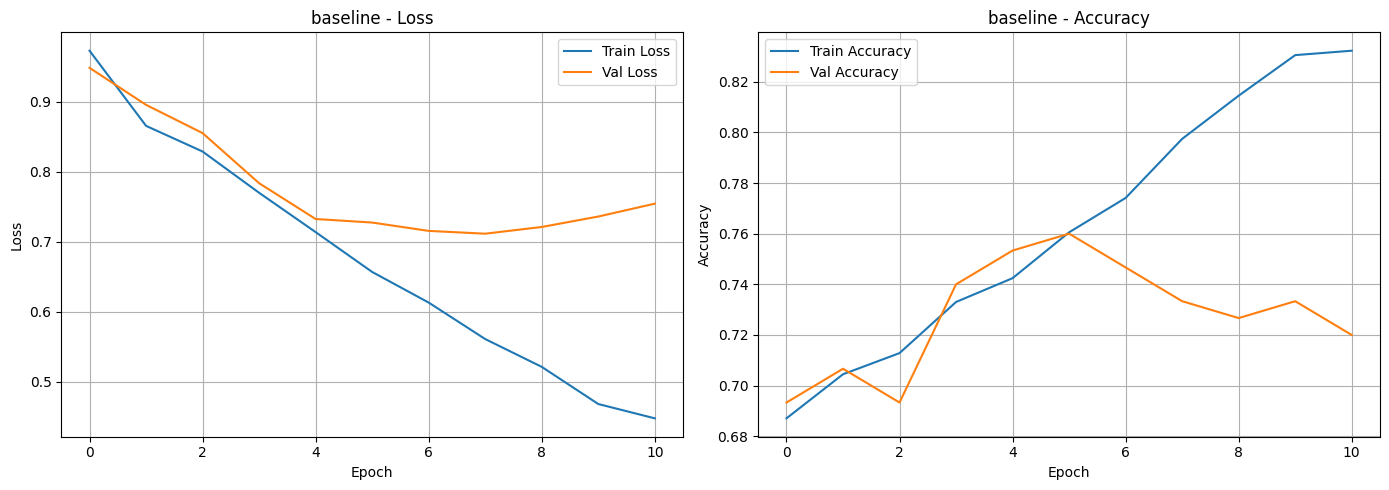

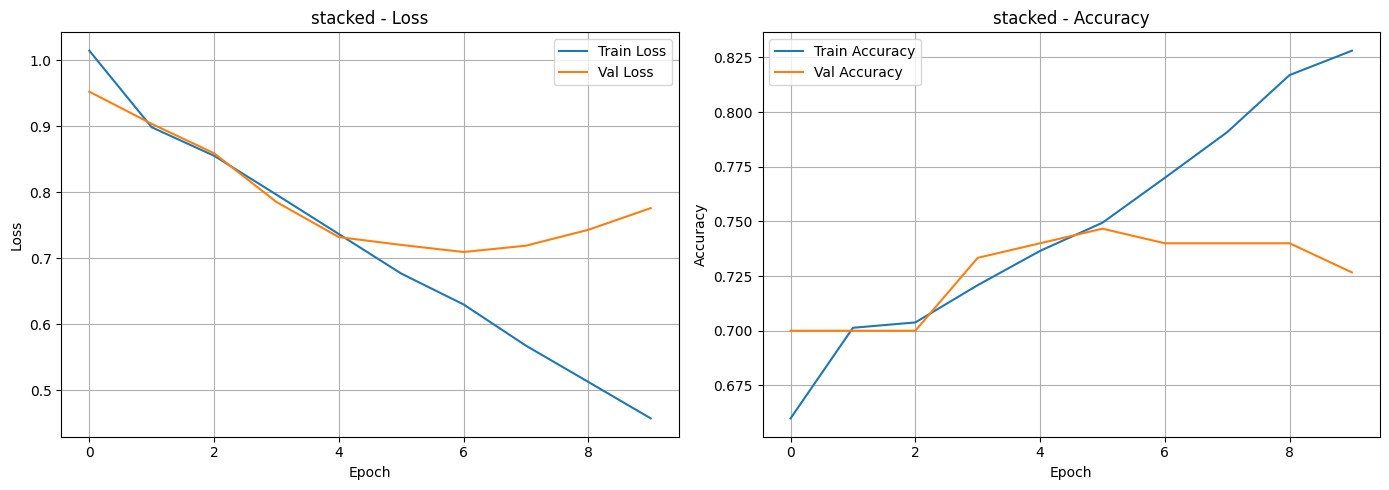

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, f1_score

# ============================================
# STEP 1: Convert texts to sequences
# ============================================

def texts_to_sequences(texts, word_to_idx):
    """Convert text strings to sequences of indices"""
    sequences = []
    for text in texts:
        tokens = text.split()
        indices = [word_to_idx.get(token, word_to_idx.get('<UNK>', 1)) for token in tokens]
        sequences.append(indices)
    return sequences

# Convert train/val/test texts to sequences
print("Converting texts to sequences...")
X_train_sequences = texts_to_sequences(train_df['cleaned_tweet'].values, word_to_idx)
X_val_sequences = texts_to_sequences(val_df['cleaned_tweet'].values, word_to_idx)
X_test_sequences = texts_to_sequences(test_df['cleaned_tweet'].values, word_to_idx)

# ============================================
# STEP 2: Pad sequences to same length
# ============================================

MAX_LENGTH = 60 # Choose based on your data

print("Padding sequences...")
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LENGTH, padding='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=MAX_LENGTH, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LENGTH, padding='post')

print(f"X_train shape: {X_train_padded.shape}")
print(f"X_val shape: {X_val_padded.shape}")
print(f"X_test shape: {X_test_padded.shape}")

# ============================================
# STEP 3: One-hot encode labels
# ============================================

NUM_CLASSES = len(train_df['label'].unique())

print("One-hot encoding labels...")
y_train_cat = to_categorical(train_df['label'].values, num_classes=NUM_CLASSES)
y_val_cat = to_categorical(val_df['label'].values, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(test_df['label'].values, num_classes=NUM_CLASSES)

print(f"y_train shape: {y_train_cat.shape}")
print(f"Number of classes: {NUM_CLASSES}")

# ============================================
# STEP 4: Train each model
# ============================================

trained_models = {}
results = {}

seeds=[42,90,77]


for model_name in models.keys():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    # Get the model
    current_model = models[model_name]
    current_model.build()
    # Compile the model
    current_model.compile(
        optimizer=AdamW(learning_rate=3e-4, weight_decay=0.01),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    # Print model summary (optional, do this once)
    current_model.summary()
    # Define callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
    # Train the model with NUMERICAL data
    history = current_model.fit(
        x=X_train_padded,        # ✅ Numerical sequences
        y=y_train_cat,           # ✅ One-hot encoded labels
        validation_data=(X_val_padded, y_val_cat),
        epochs=15,
        batch_size=128,
        callbacks=[early_stopping],
        verbose=1
    )
    # Evaluate on validation set
    val_loss, val_acc = current_model.evaluate(X_val_padded, y_val_cat, verbose=0)
    # Evaluate on test set
    test_loss, test_acc = current_model.evaluate(X_test_padded, y_test_cat, verbose=0)
    # Get detailed metrics
    y_pred_probs = current_model.predict(X_test_padded, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=-1)
    y_true = np.argmax(y_test_cat, axis=-1)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"\n{model_name} Results:")
    print(f"  Val Accuracy: {val_acc:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Test Macro F1: {macro_f1:.4f}")
    # Store results
    trained_models[model_name] = current_model
    results[model_name] = {
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'macro_f1': macro_f1,
        'history': history
    }
# ============================================
# STEP 5: Compare results
# ============================================
print(f"\n{'='*60}")
print("FINAL RESULTS COMPARISON")
print(f"{'='*60}")
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Val Accuracy': [results[m]['val_accuracy'] for m in results.keys()],
    'Test Accuracy': [results[m]['test_accuracy'] for m in results.keys()],
    'Test Macro F1': [results[m]['macro_f1'] for m in results.keys()]
})
print(results_df.to_string(index=False))
# Find best model
best_model = max(results.items(), key=lambda x: x[1]['macro_f1'])[0]
print(f"\nBest model: {best_model}")
print(f"Test Accuracy: {results[best_model]['test_accuracy']:.4f}")
print(f"Test Macro F1: {results[best_model]['macro_f1']:.4f}")
# ============================================
# STEP 6: Plot training history
# ============================================
import matplotlib.pyplot as plt
def plot_training_history(history, model_name):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Plot loss
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    axes[0].grid(True)
    # Plot accuracy
    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()
# Plot for each model
for model_name in results.keys():
    plot_training_history(results[model_name]['history'], model_name)

In [ ]:
model.evaluate()

AttributeError: 'NoneType' object has no attribute 'shape'

In [149]:
from keras.optimizers import Adam

for model in models:
    model=models[model]
    
    model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',  # Use 'sparse_categorical_crossentropy' if labels are integers
    metrics=['accuracy'])

    model.fit(x=train_df['cleaned_tweet'], y=train_df['label'], epochs=15)

ValueError: Invalid dtype: object

In [142]:
# Hyperparameters
seeds=[42,137,10]

hyper = {
    "batch_size": 256,
    "epochs": 15,
    "learning_rate": 3e-4,
    "weight_decay": 0.01
}

#df_out = pd.DataFrame(train_evaluate_model(seeds, hyper, model=models['baseline'], train_data=word_listing))
print("\n=== Summary of results ===")
df_out = df_out.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
df_out
mean_std(df_out)


=== Summary of results ===


NameError: name 'df_out' is not defined

# [Task 6 - 1.0 points] Transformers

In this section, you will use a transformer model specifically trained for hate speech detection, namely [Twitter-roBERTa-base for Hate Speech Detection](https://huggingface.co/cardiffnlp/twitter-roberta-base-hate).




### Relevant Material
- Tutorial 3

### Instructions
- **Load the Tokenizer and Model**

- **Preprocess the Dataset**:
   You will need to preprocess your dataset to prepare it for input into the model. Tokenize your text data using the appropriate tokenizer and ensure it is formatted correctly.

- **Train the Model**:
   Use the `Trainer` to train the model on your training data.

- **Evaluate the Model on the Test Set** using the same metrics used for LSTM-based models.

# [Task 7 - 0.5 points] Error Analysis

After evaluating the model, perform a brief error analysis on the **test set**:

### Instructions

 - Review the results and identify common errors.

 - Summarize your findings regarding the errors and their impact on performance (e.g. but not limited to Out-of-Vocabulary (OOV) words, data imbalance, and performance differences between the custom model and the transformer...)
 - Suggest possible solutions to address the identified errors.

# [Task 8 - 0.5 points] Report

Wrap up your experiment in a short report (up to 2 pages).

### Instructions

* Use the NLP course report template.
* Summarize each task in the report following the provided template.

### Recommendations

The report is **not a copy-paste** of graphs, tables, and command outputs.

* Summarize classification performance in Table format.
* **Do not** report command outputs or screenshots.
* Report learning curves in Figure format.
* The error analysis section should summarize your findings.


# Submission

* **Submit** your report in PDF format.
* **Submit** your python notebook.
* Make sure your notebook is **well organized**, with no temporary code, commented sections, tests, etc...
* You can upload **model weights** in a cloud repository and report the link in the report.

## Bonus Points
Bonus points are arbitrarily assigned based on significant contributions such as:
- Outstanding error analysis
- Masterclass code organization
- Suitable extensions

**Note**: bonus points are only assigned if all task points are attributed (i.e., 6/6).

**Possible Suggestions for Bonus Points:**
- **Try other preprocessing strategies**: e.g., but not limited to, explore techniques tailored specifically for tweets or  methods that are common in social media text.
- **Experiment with other custom architectures or models from HuggingFace**
- **Explore Spanish tweets**: e.g., but not limited to, leverage multilingual models to process Spanish tweets and assess their performance compared to monolingual models.

# FAQ

Please check this frequently asked questions before contacting us

### Trainable Embeddings

You are **free** to define a trainable or non-trainable Embedding layer to load the GloVe embeddings.

### Model architecture

You **should not** change the architecture of a model (i.e., its layers).

However, you are **free** to play with their hyper-parameters.


### Neural Libraries

You are **free** to use any library of your choice to implement the networks (e.g., Keras, Tensorflow, PyTorch, JAX, etc...)

### Robust Evaluation

Each model is trained with at least 3 random seeds.

Task 5 requires you to compute the average performance over the 3 seeds and its corresponding standard deviation.

### Expected Results

Task 2 leaderboard reports around 40-50 F1-score.
However, note that they perform a hierarchical classification.

That said, results around 30-40 F1-score are **expected** given the task's complexity.

### Model Selection for Analysis

To carry out the error analysis you are **free** to either

* Pick examples or perform comparisons with an individual seed run model (e.g., Baseline seed 1337)
* Perform ensembling via, for instance, majority voting to obtain a single model.

### Error Analysis

Some topics for discussion include:
   * Precision/Recall curves.
   * Confusion matrices.
   * Specific misclassified samples.


# The End

Feel free to reach out for questions/doubts!